# Efficiency Plots for SIDM

## Set up

In [1]:
# First we need to import all the necessary libraries

import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import boost_histogram as bh
import hist
import vector

# We also want to import things from sidm that are not libraries pre-installed to coffea
import sys
# Tell Python to look one directory up (which should be the root of the 'sidm' project)
sys.path.append("..") 

# Now the import should work because 'sidm' is in the path
from sidm.tools import utilities

import mplhep as hep
plt.style.use(hep.style.CMS)

In [2]:
# We also need to open the file path so we have data to work with 

file_path = "root://xcache//store/user/lpcmetx/SIDM/ULSignalSamples/2024/nanoaodYear2024.root"
file = uproot.open(file_path)

In [3]:
# Let's take a look in the file
file.keys()

['tag;1',
 'Events;1',
 'LuminosityBlocks;1',
 'Runs;1',
 'MetaData;1',
 'ParameterSets;1']

In [4]:
# The data we want will be contained in the Events TTree so we'll open that one
t = file["Events"]
t.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
bunchCrossing        | uint32_t                 | AsDtype('>u4')
orbitNumber          | uint32_t                 | AsDtype('>u4')
HTXS_njets25         | uint8_t                  | AsDtype('uint8')
HTXS_njets30         | uint8_t                  | AsDtype('uint8')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDt

### Identifying Triggers to Examine

In [5]:
# First we will define a list of all_branch_names that lets us access the trigger arrays in the Events file

#We'll define the Events object in the file

Events = file["Events"]

# We want to use the .keys() to create a simple list of all the branch names in "Events" 

all_branch_names = list(Events.keys())

# print(all_branch_names)

In [6]:
# Creating a Table for Muon Triggers (specifically looking for double muons)

# Using a for loop we can isolate the double muon Level2 triggers from the list of branches in Events
mu_hlt_triggers = []
for name in all_branch_names:
    if name.startswith("HLT_") and "DoubleL2Mu" in name:
        mu_hlt_triggers.append(name)


# Create table that prints the trigger name, number of events that pass and the pass rate

N_EVENTS = Events.num_entries # Get the total number of events

# Analyze Triggers 

analysis_results = []

for name in mu_hlt_triggers: 
    mask_array = Events[name].array()

    # Count the number of events that pass 
    passed_count = np.sum(mask_array)
    
    # Calculate the percentage of events that pass the trigger 
    pass_percentage = (passed_count / N_EVENTS) * 100
    
    # Store the results by appending them to the analysis results array
    analysis_results.append({
        "name": name,
        "count": passed_count,
        "percent": pass_percentage
    })

# Sort and Display Results

sorted_results = sorted(analysis_results, key=lambda x: x["count"], reverse=True)

# Make table

print(f"DOUBLEL2MU TRIGGER REPORT (Total Events = {N_EVENTS})")  # title line
print("-" * 86)                                            # separate the title with a bunch of dashes

print(f"{'Trigger Name':<57} | {'Events Passed':>12}| {'Pass Rate':>10}")  # make 3 columns 
print("-" * 86)

# Print the results
for result in sorted_results:
    print(
        f"{result['name']:<57} | "
        f"{result['count']:>12,} | "  
        f"{result['percent']:>8.2f}%"
    )


DOUBLEL2MU TRIGGER REPORT (Total Events = 9999)
--------------------------------------------------------------------------------------
Trigger Name                                              | Events Passed|  Pass Rate
--------------------------------------------------------------------------------------
HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4                         |        7,381 |    73.82%
HLT_DoubleL2Mu23NoVtx_2Cha                                |        7,246 |    72.47%
HLT_DoubleL2Mu25NoVtx_2Cha                                |        7,143 |    71.44%
HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4                         |        7,138 |    71.39%
HLT_DoubleL2Mu50                                          |        6,332 |    63.33%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4              |        5,579 |    55.80%
HLT_DoubleL2Mu23NoVtx_2Cha_CosmicSeed                     |        5,562 |    55.63%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed                     |        5,422 |    54.23%
HLT_DoubleL2

In [7]:
# for name in mu_hlt_triggers:
#   print(len(Events[name].array()))

## Efficiency Plots

### Plots with LooseID applied and then masks evaluated

In [8]:
# First define some variables we will need
muons = t.arrays(
    ["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "Muon_charge"]
)

Muon_pt = muons["Muon_pt"]

In [9]:
looseId = Events["Muon_looseId"].array()

Muon_pt_lID = Muon_pt[looseId]

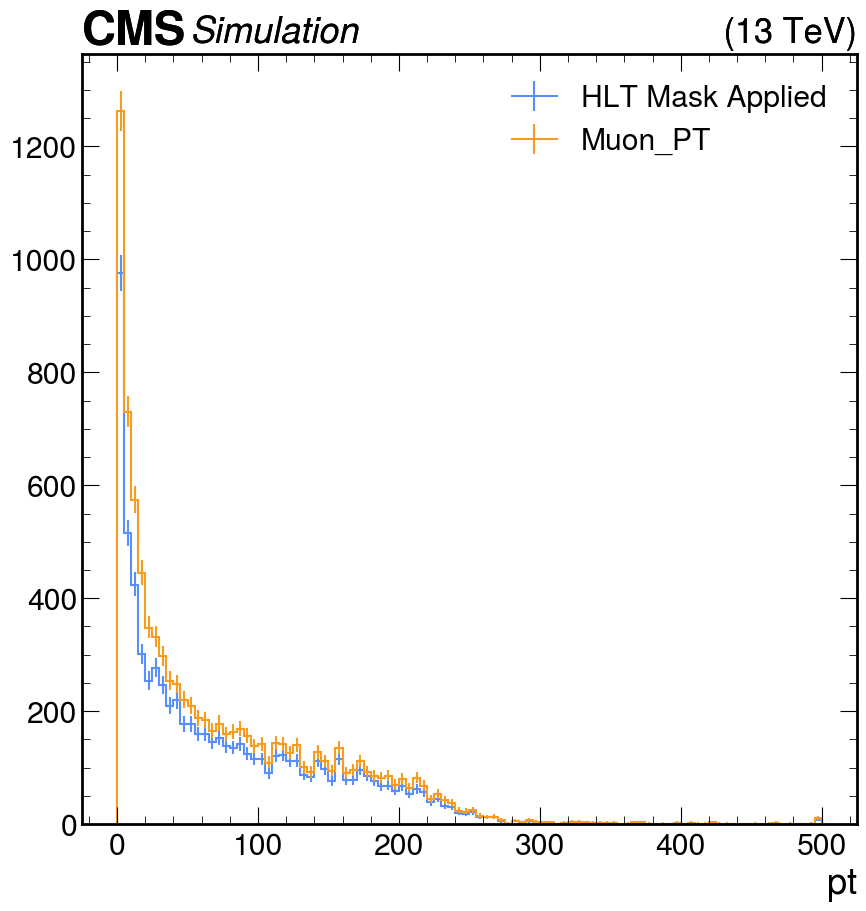

In [10]:
# Plot for HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4

HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4 = Events["HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4"].array()   # In the table made previously this had a 73.82% pass rate

#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(Muon_pt_lID[HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4]))
denominator.fill(ak.flatten(Muon_pt_lID))

#Plot both on the same figure
utilities.plot(numerator, label = "HLT Mask Applied")
utilities.plot(denominator, label ="Muon_PT")
plt.legend(loc = 'upper right')


/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:143: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:148: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:149: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


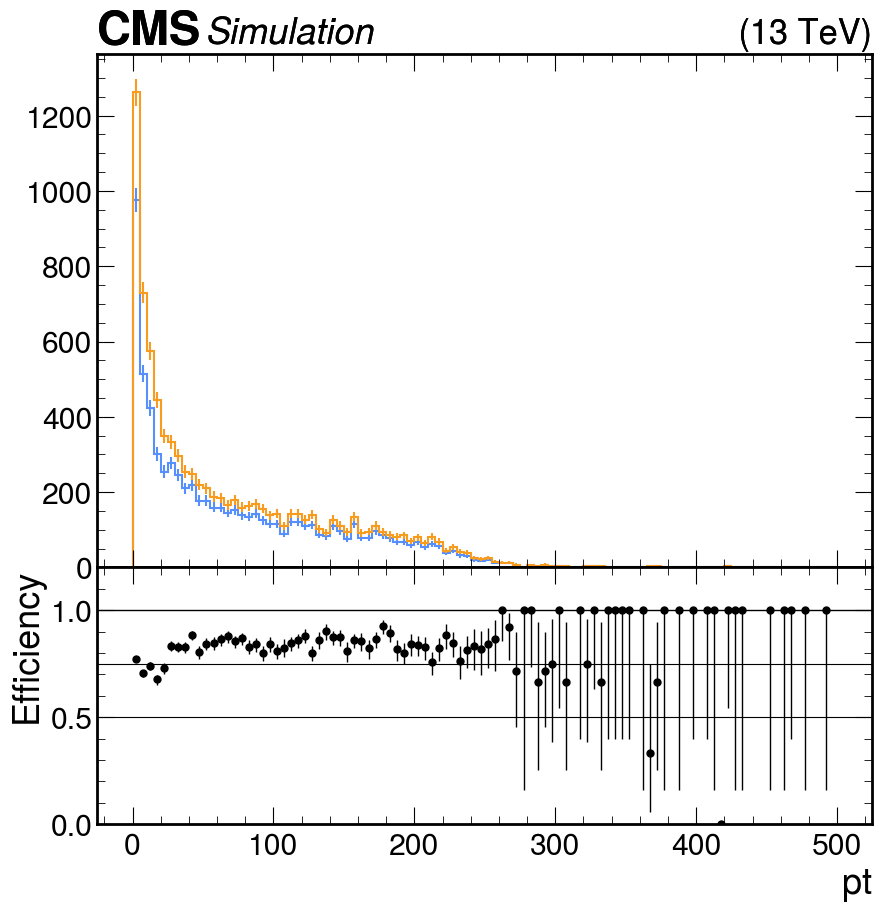

In [11]:
#Plot both along with their ratio. The warnings occur if there are any bins with zero counts and can be safely ignored. 
#If the numerator is ever greater than the denominator in any bin, this will throw an error

plot_result = utilities.plot_ratio(numerator, denominator)

# Use a for loop to check if the plot function failed to return the axes objects (returned None)
if plot_result is None:
    # Handle the failure: retrieve axes from Matplotlib's global state
    fig = plt.gcf()
    all_axes = fig.get_axes()
    if len(all_axes) >= 2:
        ratio_ax = all_axes[1]
    else:
        # Exit if plot still isn't usable
        print("ERROR: Could not retrieve axes from figure.")
        ratio_ax = None
else:
    # Handle the success: unpack the returned objects
    fig, (ax1, ratio_ax) = plot_result
    
# Apply any changes (including horizontal line) if the ratio axis was successfully retrieved
if ratio_ax is not None:

    # Line 1: Thin black line at 0.5 (Solid)
    ratio_ax.axhline(y=0.5, color='black', linestyle='-', linewidth=0.8)
    
    # Line 2: Thin black line at 1 (Solid)
    ratio_ax.axhline(y=1, color='black', linestyle='-', linewidth=1)
    
    # Line 3: Thin black line at 0.75 (Solid)
    ratio_ax.axhline(y=0.75, color='black', linestyle='-', linewidth=0.8)
    

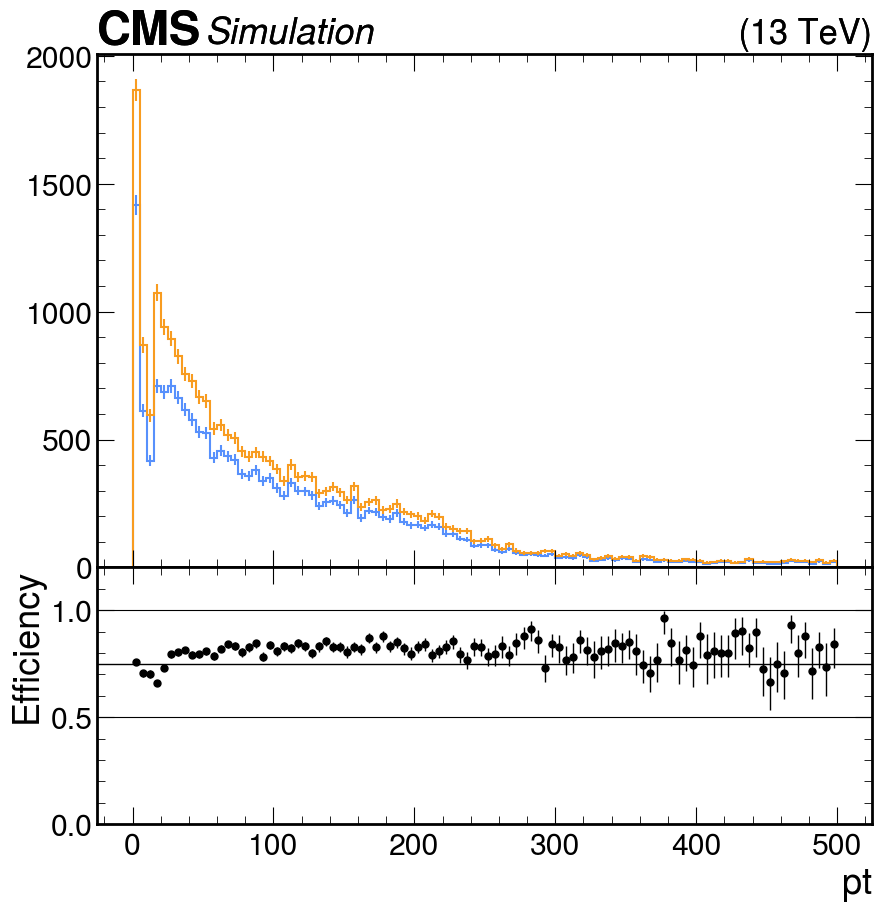

In [12]:
# Plot for HLT_DoubleL2Mu23NoVtx_2Cha (consolidated code to output only one plot that has the efficiency)

# Now define the mask we will use

HLT_DoubleL2Mu23NoVtx_2Cha = Events["HLT_DoubleL2Mu23NoVtx_2Cha"].array()   # In the table made previously this had a 63.33% pass rate

#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(Muon_pt[HLT_DoubleL2Mu23NoVtx_2Cha]))
denominator.fill(ak.flatten(Muon_pt))

# 1. Plot the ratio. This single command plots the numerator/denominator in the top
#    panel and the ratio in the bottom panel (the subplot).
plot_result = utilities.plot_ratio(
    numerator,
    denominator, 
    error_opts={"marker": "o", "ms": 4}
)

# Use a for loop to check if the plot function failed to return the axes objects (returned None)
if plot_result is None:
    # Handle the failure: retrieve axes from Matplotlib's global state
    fig = plt.gcf()
    all_axes = fig.get_axes()
    if len(all_axes) >= 2:
        ratio_ax = all_axes[1]
    else:
        # Exit if plot still isn't usable
        print("ERROR: Could not retrieve axes from figure.")
        ratio_ax = None
else:
    # Handle the success: unpack the returned objects
    fig, (ax1, ratio_ax) = plot_result
    
# 3. Apply the horizontal line if the ratio axis was successfully retrieved
if ratio_ax is not None:

    # Line 1: The original thin black line at 0.5 (Solid)
    ratio_ax.axhline(y=0.5, color='black', linestyle='-', linewidth=0.8)
    
    # Line 2: A dashed, slightly thicker gray line at 1
    ratio_ax.axhline(y=1, color='black', linestyle='-', linewidth=0.8)
    
    # Line 3: A dotted red line at 0.75 (perhaps a warning boundary)
    ratio_ax.axhline(y=0.75, color='black', linestyle='-', linewidth=1)
    

## Combined triggers Efficiency plot

In [13]:
# First we need to create a mask that is a combined mask for all DoubleL2Mu triggers

target_triggers = [
    name for name in all_branch_names
    if name.startswith("HLT_") and "DoubleL2Mu" in name
]

if not target_triggers:
    print("No HLT_DoubleL2Mu triggers found. Check branch naming.")
else:
    print(f"Found {len(target_triggers)} triggers to combine.")

    # Create the Combined Mask (The "OR" statement)
    # Initialize the combined mask with False. 
    # It must have the same length as the number of events (Events.num_entries or len(Events))
    
    all_masks = [Events[trigger_name].array() for trigger_name in target_triggers]
    
    # 2. Use np.logical_or.reduce to combine them all with a logical OR
    # This applies the OR operation cumulatively across all arrays in the list.
    combined_mask = np.logical_or.reduce(all_masks)

Found 16 triggers to combine.


/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:143: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:148: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:149: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


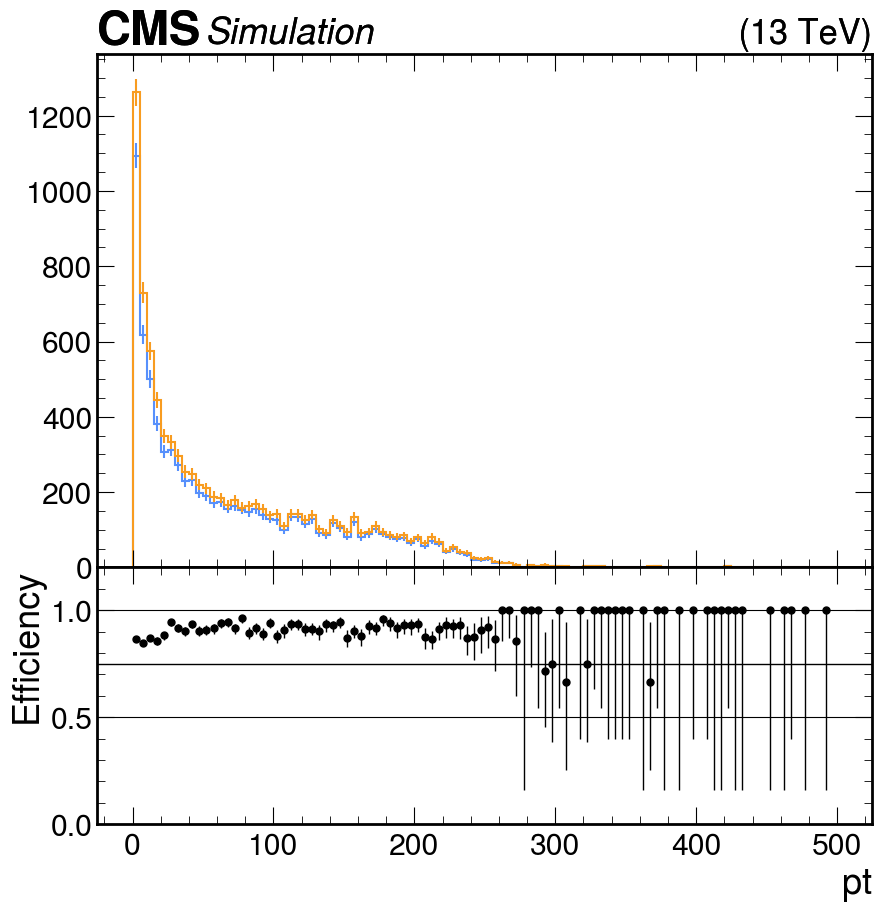

In [14]:
# Plot for combined masks 

#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(Muon_pt_lID[combined_mask]))
denominator.fill(ak.flatten(Muon_pt_lID))

# 1. Plot the ratio. This single command plots the numerator/denominator in the top
#    panel and the ratio in the bottom panel (the subplot).
plot_result = utilities.plot_ratio(
    numerator,
    denominator, 
    error_opts={"marker": "o", "ms": 4}
)

# Use a for loop to check if the plot function failed to return the axes objects (returned None)
if plot_result is None:
    # Handle the failure: retrieve axes from Matplotlib's global state
    fig = plt.gcf()
    all_axes = fig.get_axes()
    if len(all_axes) >= 2:
        ratio_ax = all_axes[1]
    else:
        # Exit if plot still isn't usable
        print("ERROR: Could not retrieve axes from figure.")
        ratio_ax = None
else:
    # Handle the success: unpack the returned objects
    fig, (ax1, ratio_ax) = plot_result
    
# 3. Apply the horizontal line if the ratio axis was successfully retrieved
if ratio_ax is not None:

    # Line 1: The original thin black line at 0.5 (Solid)
    ratio_ax.axhline(y=0.5, color='black', linestyle='-', linewidth=0.8)
    
    # Line 2: A dashed, slightly thicker gray line at 1
    ratio_ax.axhline(y=1, color='black', linestyle='-', linewidth=0.8)
    
    # Line 3: A dotted red line at 0.75 (perhaps a warning boundary)
    ratio_ax.axhline(y=0.75, color='black', linestyle='-', linewidth=1)
    

In [15]:
# lets also get the overall efficiency

# Count the number of events that pass
passed_count = np.sum(combined_mask)

# Calculate the percentage of events that pass the trigger
# Note: Use N_EVENTS here, which is the total length of the mask
pass_percentage = (passed_count / N_EVENTS) * 100

print(f"DOUBLEL2MU COMBINED TRIGGER")      # title line
print("-" * 86)                             # separate the title with a bunch of dashes

# Header row
print(f"{'Trigger Name':<57} | {'Events Passed':>12} | {'Pass Rate':>10}")
print("-" * 86)

# Print the results for the combined mask
# FIX: The format specifier is changed from :>,12 to :>12, 
# to correctly place the comma separator at the end of the format spec.
print(
    f"{'Combined Mask':<57} | "  
    f"{passed_count:>12,} | "     # FIXED: Comma separator moved to the end
    f"{pass_percentage:>10.2f}%"  # Adjusted width to 10 for better alignment
)

DOUBLEL2MU COMBINED TRIGGER
--------------------------------------------------------------------------------------
Trigger Name                                              | Events Passed |  Pass Rate
--------------------------------------------------------------------------------------
Combined Mask                                             |        8,514 |      85.15%


Lets add the combined mask to an efficiency plot

/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:143: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:148: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/../sidm/tools/utilities.py:149: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


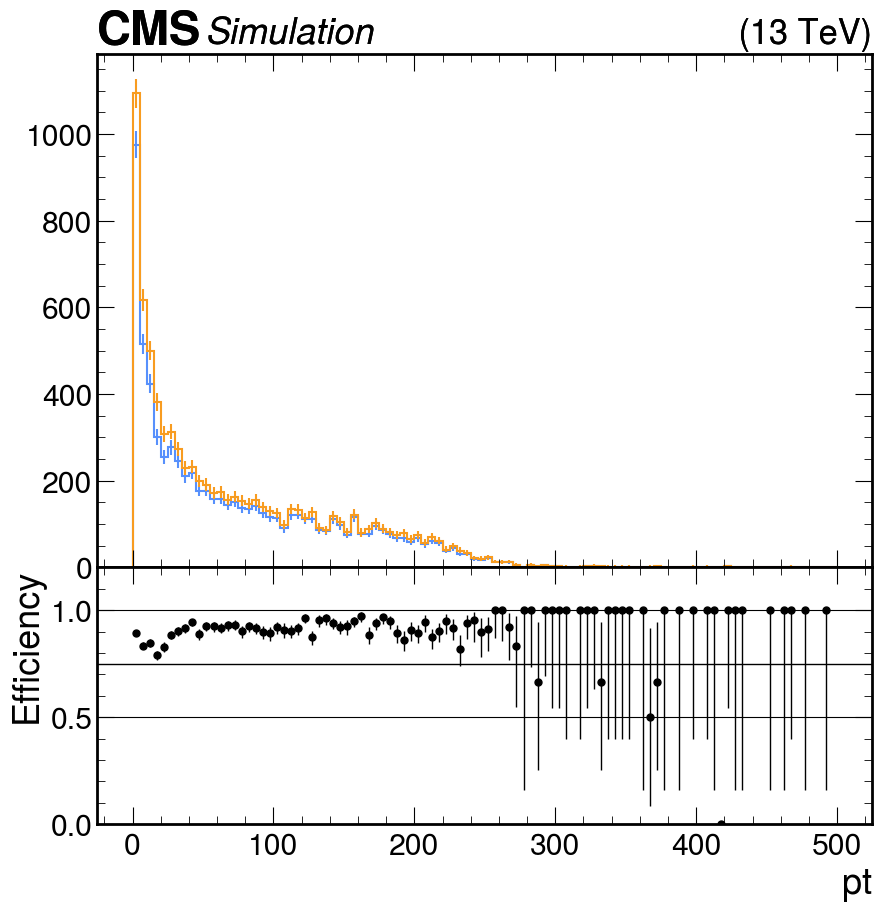

In [16]:
# Plot for combined masks 

#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(Muon_pt_lID[HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4]))
denominator.fill(ak.flatten(Muon_pt_lID[combined_mask]))

# 1. Plot the ratio. This single command plots the numerator/denominator in the top
#    panel and the ratio in the bottom panel (the subplot).
plot_result = utilities.plot_ratio(
    numerator,
    denominator, 
    error_opts={"marker": "o", "ms": 4}
)

# Use a for loop to check if the plot function failed to return the axes objects (returned None)
if plot_result is None:
    # Handle the failure: retrieve axes from Matplotlib's global state
    fig = plt.gcf()
    all_axes = fig.get_axes()
    if len(all_axes) >= 2:
        ratio_ax = all_axes[1]
    else:
        # Exit if plot still isn't usable
        print("ERROR: Could not retrieve axes from figure.")
        ratio_ax = None

else:
    # Handle the success: unpack the returned objects
    fig, (ax1, ratio_ax) = plot_result
    
# 3. Apply the horizontal line if the ratio axis was successfully retrieved
if ratio_ax is not None:

    # Line 1: The original thin black line at 0.5 (Solid)
    ratio_ax.axhline(y=0.5, color='black', linestyle='-', linewidth=0.8)
    
    # Line 2: A dashed, slightly thicker gray line at 1
    ratio_ax.axhline(y=1, color='black', linestyle='-', linewidth=0.8)
    
    # Line 3: A dotted red line at 0.75 (perhaps a warning boundary)
    ratio_ax.axhline(y=0.75, color='black', linestyle='-', linewidth=1)
    
# This will plot the efficiency of an HLT_DoubleL2Mu mask in comparison with the combined mask

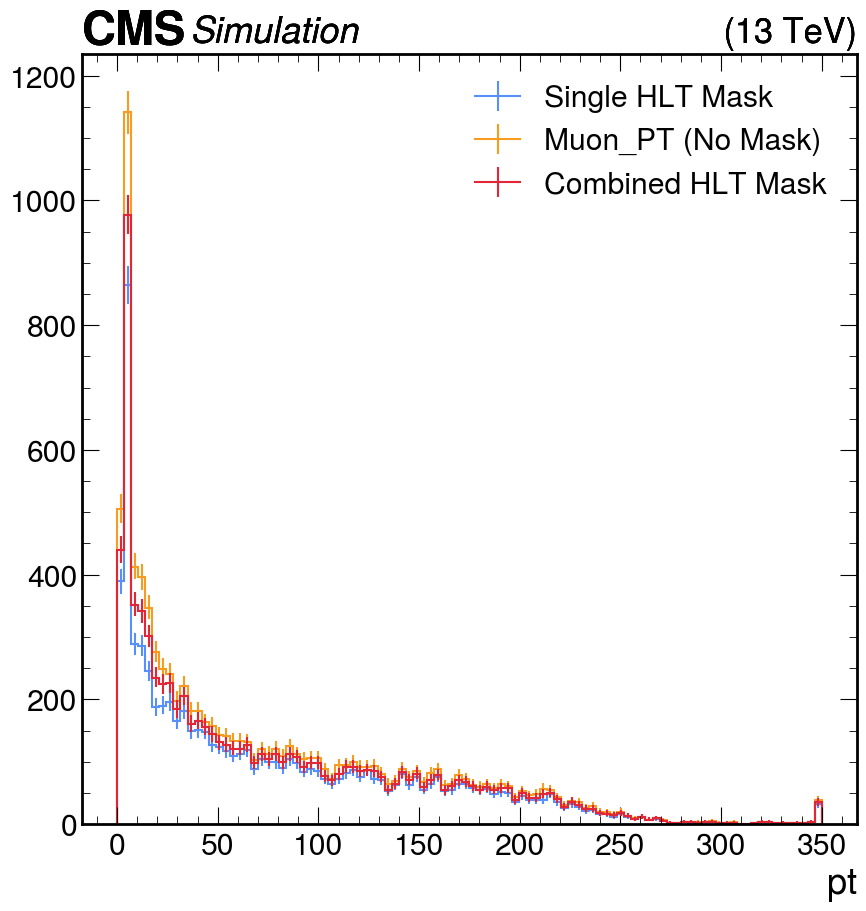

In [18]:
# Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 350, name="pt")

# Histogram 1: Single HLT Mask Applied
single_mask_hist = hist.Hist(pt_axis)
# Histogram 2: No Mask (Denominator)
denominator_hist = hist.Hist(pt_axis)
# Histogram 3: Combined Mask Applied (New Set)
combined_mask_hist = hist.Hist(pt_axis) 

# Fill the histograms with the flattened arrays

# Set 1: Single HLT Mask
single_mask_hist.fill(ak.flatten(Muon_pt_lID[HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4]))

# Set 2: No Mask (Denominator)
denominator_hist.fill(ak.flatten(Muon_pt_lID))

# NEW LOGIC FOR SET 3: Combined Mask
combined_mask_hist.fill(ak.flatten(Muon_pt_lID[combined_mask]))

# Plot all three on the same figure
utilities.plot(single_mask_hist, label="Single HLT Mask")
utilities.plot(denominator_hist, label="Muon_PT (No Mask)")
utilities.plot(combined_mask_hist, label="Combined HLT Mask") # Plot the new set

plt.legend(loc='upper right')

## Using 2nd highest Muon PT

In [33]:
GenPart_pt = Events['GenPart_pt'].array()

list(GenPart_pt[:5])

[<Array [0, 0, 2.93e-14, 36.9, ..., 0.383, 0.0458, 0.192] type='27 * float32'>,
 <Array [0, 0, 1.42e-14, 6.83, ..., 8.41, 1.9, 7.92, 1.79] type='14 * float32'>,
 <Array [0, 0, 2.84e-14, 3.68, ..., 0.456, 4.59, 0.719] type='19 * float32'>,
 <Array [0, 0, 0, 13.1, ..., 0.729, 6.75, 0.0529, 0.0391] type='18 * float32'>,
 <Array [0, 0, 2.84e-14, 2.8, ..., 2.32, 8.66, 1.75, 2.16] type='19 * float32'>]

In [41]:
# First I need to get the muons from the GenPart_pt, to do this I can apply the gen_mu_mask

GenPart_pdgId = Events['GenPart_pdgId'].array()
gen_mu_mask = abs(GenPart_pdgId) == 13

GenMuon_pt = GenPart_pt[gen_mu_mask]

In [42]:
# I want a better way to look at the jagged array so I can check later if I actually extracted the second highest PT

# Convert the first 5 events to a Python list for easy iteration and printing
muon_pt_list = GenMuon_pt[:5].to_list()

for i, pt_values in enumerate(muon_pt_list):
    # Format the pT values to 2 decimal places for clean output
    formatted_pts = [f"{pt:.2f}" for pt in pt_values]
    
    # Check if we successfully extracted the 2nd highest pT for this event
    # Note: We use the value from the 'second_highest_pt' array created in Step 4
    second_pt_val = second_highest_pt[i]
    
    # Print the event index, all muon pT values, and the extracted 2nd highest pT
    if second_pt_val > 0:
        extracted_pt_info = f"-> Extracted 2nd highest pT: {second_pt_val:.2f}"
    else:
        extracted_pt_info = "-> Insufficient muons (pT not extracted)"
        
    print(f"Event {i:04d}: [{', '.join(formatted_pts)}] {extracted_pt_info}")

# The list conversion and print loop prevents the '...' truncation.

Event 0000: [232.50, 31.25, 30.88, 232.50, 232.50, 30.88, 81.25, 155.00, 81.25, 155.00] -> Extracted 2nd highest pT: 236.50
Event 0001: [26.81, 212.00, 137.00, 107.50] -> Extracted 2nd highest pT: 238.50
Event 0002: [64.00, 183.50, 71.00, 180.00, 177.50, 70.75] -> Extracted 2nd highest pT: 247.50
Event 0003: [170.00, 70.75, 180.50, 68.50] -> Extracted 2nd highest pT: 241.00
Event 0004: [120.75, 130.50, 35.50, 213.00] -> Extracted 2nd highest pT: 248.50


In [43]:
# Now lets try to extract the second highest PT values, I can compare them to the arrays I jsut displayed to check that its working
# 1. Sort the muon pT values within each event in descending order
# Example: [[50, 20], [10, 5, 80], []] -> [[50, 20], [80, 10, 5], []]
sorted_muon_pt = ak.sort(GenMuon_pt, ascending=False)

# 2. Extract the element at index 1 (the 2nd highest pT)
# Awkward Array automatically returns None for events where index 1 does not exist (events with 0 or 1 muon)
second_muon_pt_or_none = sorted_muon_pt[:, 1]

# 3. Replace the 'None' values with a large negative sentinel value (-1.0)
# This ensures the resulting array is flat and has exactly N_EVENTS length
second_highest_pt = ak.fill_none(second_muon_pt_or_none, -1.0)

# Now we can display the results, I want to double check that the final PT array has the same length as N_Events
# I also want to know how many of the events had 0 or 1 muons (which I made it so the PT value would be -1.0 
print(f"Total Events: {N_EVENTS}")
print(f"Events with 0 or 1 muon (where pT is -1.0): {np.sum(second_highest_pt == -1.0)}")
print(f"Shape of final pT array: {len(second_highest_pt)}")
print("\nFirst 10 values of the extracted 2nd highest pT array:")

# For this final line, I can change the cut off to determine how many I display, but the entire second_highest_pt array should have length 9999
print(second_highest_pt[:15])

Total Events: 9999
Events with 0 or 1 muon (where pT is -1.0): 0
Shape of final pT array: 9999

First 10 values of the extracted 2nd highest pT array:
[232, 137, 180, 170, 130, 149, 83, ..., 127, 182, 100, 222, 50.8, 95.2, 185]


In [44]:
# Lets see if we can create an efficiency plot using the new second_highest_pt array.
